# General-Agreement run-to-run randomness (repeat ×10)

`gpt-5.4-mini-2026-03-17` is a reasoning model: temperature is pinned to 1.0 and
`seed` is unsupported, so the per-document integer agreement scores are **not
reproducible** across runs. This notebook checks whether the **time-series
signals** we report survive that run-to-run randomness.

**Design.** The *identical* input (`df_documents_general_merged.csv`, 1,280 docs,
scoring columns stripped) was scored **10 times** — `v1 … v10` — with the same
recipe (prompt `simple_v2`, temperature 1.0, max-output 16384). Any difference
between runs is pure model stochasticity, not data or config change.

Produced by `scripts/adhoc/run_general_agreement_repeat10.sh --yes`.

Sections:
1. Load the 10 runs + completeness check
2. **Time-series robustness** — yearly means, all 10 runs overlaid
3. **Fixed-effects trends** — two-way FE `~ C(year) + C(country)`, dispersion across runs

Method (99→NaN sentinel handling, Stata-style FE margins with country-clustered
SEs) mirrors `notebook_check_new_prompt_v2.ipynb`; the comparison axis is *runs*
instead of *prompt versions*.

In [23]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

REPEAT_DIR = Path("/data/home/xiong/data/Fund/CSR/Tractions/output/adhoc/general_agreement_repeat10")
N_REPS = 10

# Document key: identical across runs because the input is identical.
KEY = "Print ISBN"
SCORE_COLS = [
    "Agreement_General", "Agreement_Monetary", "Agreement_Fiscal",
    "Agreement_External", "Agreement_Financial", "Agreement_Real", "Agreement_Other",
]
# Per-sector scores use 99 = "insufficient info"; Agreement_General does not.
SENTINEL_COLS = [c for c in SCORE_COLS if c != "Agreement_General"]
YEAR_MIN, YEAR_MAX = 2015, 2026

In [24]:
# --- Load all 10 runs into one long (tidy) frame -----------------------------
frames = []
for i in range(1, N_REPS + 1):
    p = REPEAT_DIR / f"v{i}" / f"df_documents_general_v{i}.csv"
    if not p.exists():
        print(f"  [missing] {p}")
        continue
    d = pd.read_csv(p, low_memory=False)
    d["run"] = i
    frames.append(d)

long = pd.concat(frames, ignore_index=True)
print(f"Loaded {long['run'].nunique()} runs, {len(long)} total rows "
      f"({len(long)//max(long['run'].nunique(),1)} docs/run expected ~1280)")

# 99 sentinel -> NaN so it never contaminates means/variances.
for c in SENTINEL_COLS:
    long[c] = long[c].replace(99, np.nan)

long["year"] = pd.to_numeric(long["year"], errors="coerce").astype("Int64")
# Row-mean of the 6 per-sector scores (sentinel already NaN), per the reference nb.
long["sector_avg"] = long[SENTINEL_COLS].mean(axis=1)
long.head()

Loaded 10 runs, 12800 total rows (1280 docs/run expected ~1280)


,index,Print ISBN,staff,buff,country,year,publication_date,id,Agreement_General,Agreement_Monetary,Agreement_Fiscal,Agreement_External,Agreement_Financial,Agreement_Real,Agreement_Other,Monetary_Sector,Fiscal_Sector,External_Sector,Financial_Sector,Real_Sector,Other_Sector,run,sector_avg
0,0,9781513500676,1. Finland has suffered three years of recessi...,17. The authorities agreed with staff on the s...,Finland,2015,11/17/2015,0,2,NaN,2.0,2.0,1.0,2.0,3.0,[],[{'area': 'pace of consolidation and frontload...,[],[{'area': 'timing of macroprudential buffer le...,[{'area': 'growth impact and pace of recovery'...,"[{'area': 'scope of wage bargaining reform', '...",1,2.000000
1,1,9781513560069,"1. Spain’s recovery has gathered speed, but un...",9. The authorities have higher forecasts for m...,Spain,2015,08/14/2015,1,2,NaN,1.0,1.0,2.0,2.0,2.0,[],[{'area': 'pace of fiscal consolidation / defi...,[{'area': 'degree of external imbalance/REER o...,[{'area': 'treatment of public creditors in in...,[{'area': 'timing of additional labor market r...,[{'area': 'need for further firm-growth and co...,1,1.600000
2,2,9781484304389,1. Aruba is a small open economy with high liv...,21. The authorities expected a stronger econom...,Kingdom of the Netherlands - Aruba,2017,06/15/2017,2,1,1.0,-1.0,-1.0,1.0,-1.0,-1.0,[],[{'area': 'additional structural fiscal measur...,[{'area': 'domestic borrowing and reserve pres...,[{'area': 'government domestic borrowing crowd...,"[{'area': 'growth outlook', 'severity': -3}, {...","[{'area': 'labor market regulations', 'severit...",1,-0.333333
3,3,9781616357382,1. Moldova’s previous ECF/EFF arrangements sup...,8. The authorities broadly agreed with staff’s...,Republic of Moldova,2021,01/04/2022,3,4,4.0,3.0,3.0,4.0,2.0,4.0,[],[{'area': 'pace of fiscal consolidation and de...,[{'area': 'exchange rate flexibility and FX in...,[{'area': 'scope and sequencing of non-bank su...,"[{'area': 'growth upside vs baseline outlook',...","[{'area': 'sequencing of governance reforms', ...",1,3.333333
4,4,9781484378120,1. The 2018 Article IV Consultation took place...,11. The authorities share staff’s concerns abo...,Trinidad and Tobago,2018,09/25/2018,4,2,0.0,2.0,0.0,2.0,1.0,2.0,"[{'area': 'exchange rate flexibility', 'severi...","[{'area': 'pace of fiscal adjustment', 'severi...","[{'area': 'exchange rate regime', 'severity': ...",[],"[{'area': 'growth outlook', 'severity': -1}]","[{'area': 'urgency of structural reforms', 'se...",1,1.166667


In [25]:
# Export the 'long' DataFrame, excluding 'staff' and 'buff' columns, to CSV in the specified directory
export_cols = [col for col in long.columns if col not in ['staff', 'buff']]
output_path = REPEAT_DIR / "longdata_with_10_runs.csv"
long[export_cols].to_csv(output_path, index=False)

## 1 · Completeness check

Every run should have the same 1,280 documents. Confirm no run silently dropped
rows or returned unparseable (`error`) responses.

In [3]:
rows_per_run = long.groupby("run").size().rename("rows")
keys_per_run = long.groupby("run")[KEY].nunique().rename("unique_docs")
err = (long.get("error").notna().groupby(long["run"]).sum().rename("error_rows")
       if "error" in long.columns else pd.Series(0, index=rows_per_run.index, name="error_rows"))
summary = pd.concat([rows_per_run, keys_per_run, err], axis=1)
print(summary)

common = set.intersection(*(set(g[KEY]) for _, g in long.groupby("run")))
print(f"\nDocuments present in ALL {long['run'].nunique()} runs: {len(common)}")

# Restrict every downstream analysis to docs scored in all runs (fair comparison).
long = long[long[KEY].isin(common)].copy()

     rows  unique_docs  error_rows
run                               
1    1280         1280           0
2    1280         1280           0
3    1280         1280           0
4    1280         1280           0
5    1280         1280           0
6    1280         1280           0
7    1280         1280           0
8    1280         1280           0
9    1280         1280           0
10   1280         1280           0

Documents present in ALL 10 runs: 1280


## 2 · Time-series robustness

Yearly mean of each score, with **all 10 runs overlaid**. If the temporal trend
is robust to model randomness, the 10 lines should bunch tightly; a wide spread
in a given year flags a year whose signal is fragile.

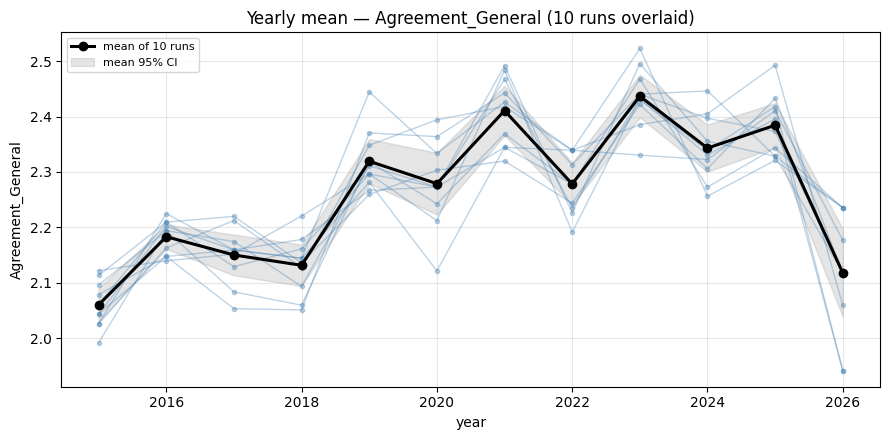

In [9]:
def yearly_means_by_run(df, col):
    d = df.dropna(subset=[col, "year"]).copy()
    d = d[(d["year"] >= YEAR_MIN) & (d["year"] <= YEAR_MAX)]
    return d.groupby(["run", "year"])[col].mean().reset_index()

def plot_year_overlay(col, ax=None):
    import scipy.stats as stats

    ym = yearly_means_by_run(long, col)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 4.5))
    for r, g in ym.groupby("run"):
        ax.plot(g["year"], g[col], color="steelblue", alpha=0.35, lw=1, marker="o", ms=3)
    # mean-of-runs (thick) + 95% confidence interval band
    agg = ym.groupby("year")[col].agg(["mean", "std", "count"]).reset_index()
    ax.plot(agg["year"], agg["mean"], color="black", lw=2.2, marker="o", label="mean of 10 runs")

    # Calculate 95% confidence interval
    ci = stats.t.ppf(0.975, agg["count"]-1)
    ci_lo = agg["mean"] - ci * agg["std"] / agg["count"]**0.5
    ci_hi = agg["mean"] + ci * agg["std"] / agg["count"]**0.5

    # Change CI color to grey as requested
    ax.fill_between(agg["year"], ci_lo, ci_hi, color="grey", alpha=0.2, label="mean 95% CI")
    ax.set_title(f"Yearly mean — {col} (10 runs overlaid)")
    ax.set_xlabel("year"); ax.set_ylabel(col); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    if standalone:
        plt.tight_layout(); plt.show()

plot_year_overlay("Agreement_General")

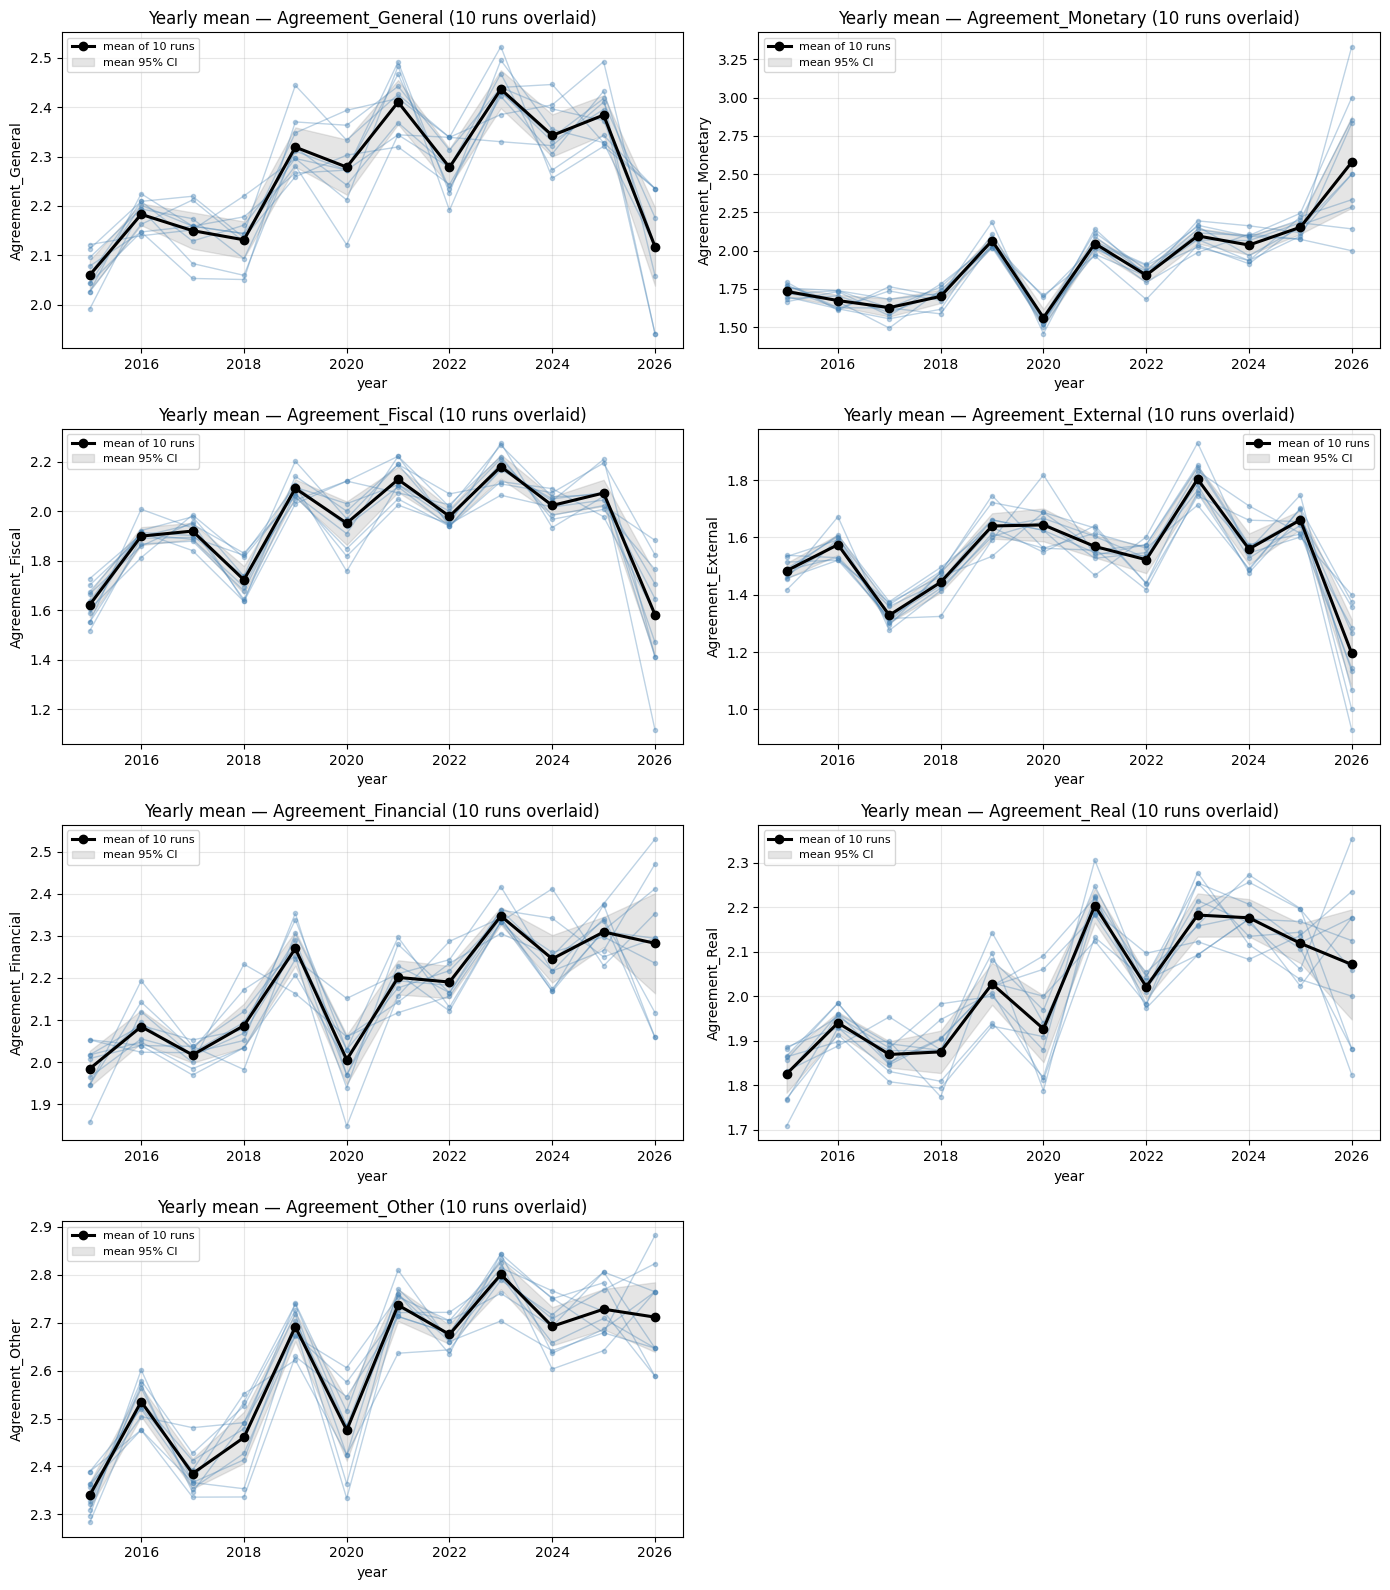

In [10]:
# All 7 scores in a grid.
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, c in zip(axes.flat, SCORE_COLS):
    plot_year_overlay(c, ax=ax)
axes.flat[-1].axis("off")  # 7 scores in 8 slots
plt.tight_layout(); plt.show()

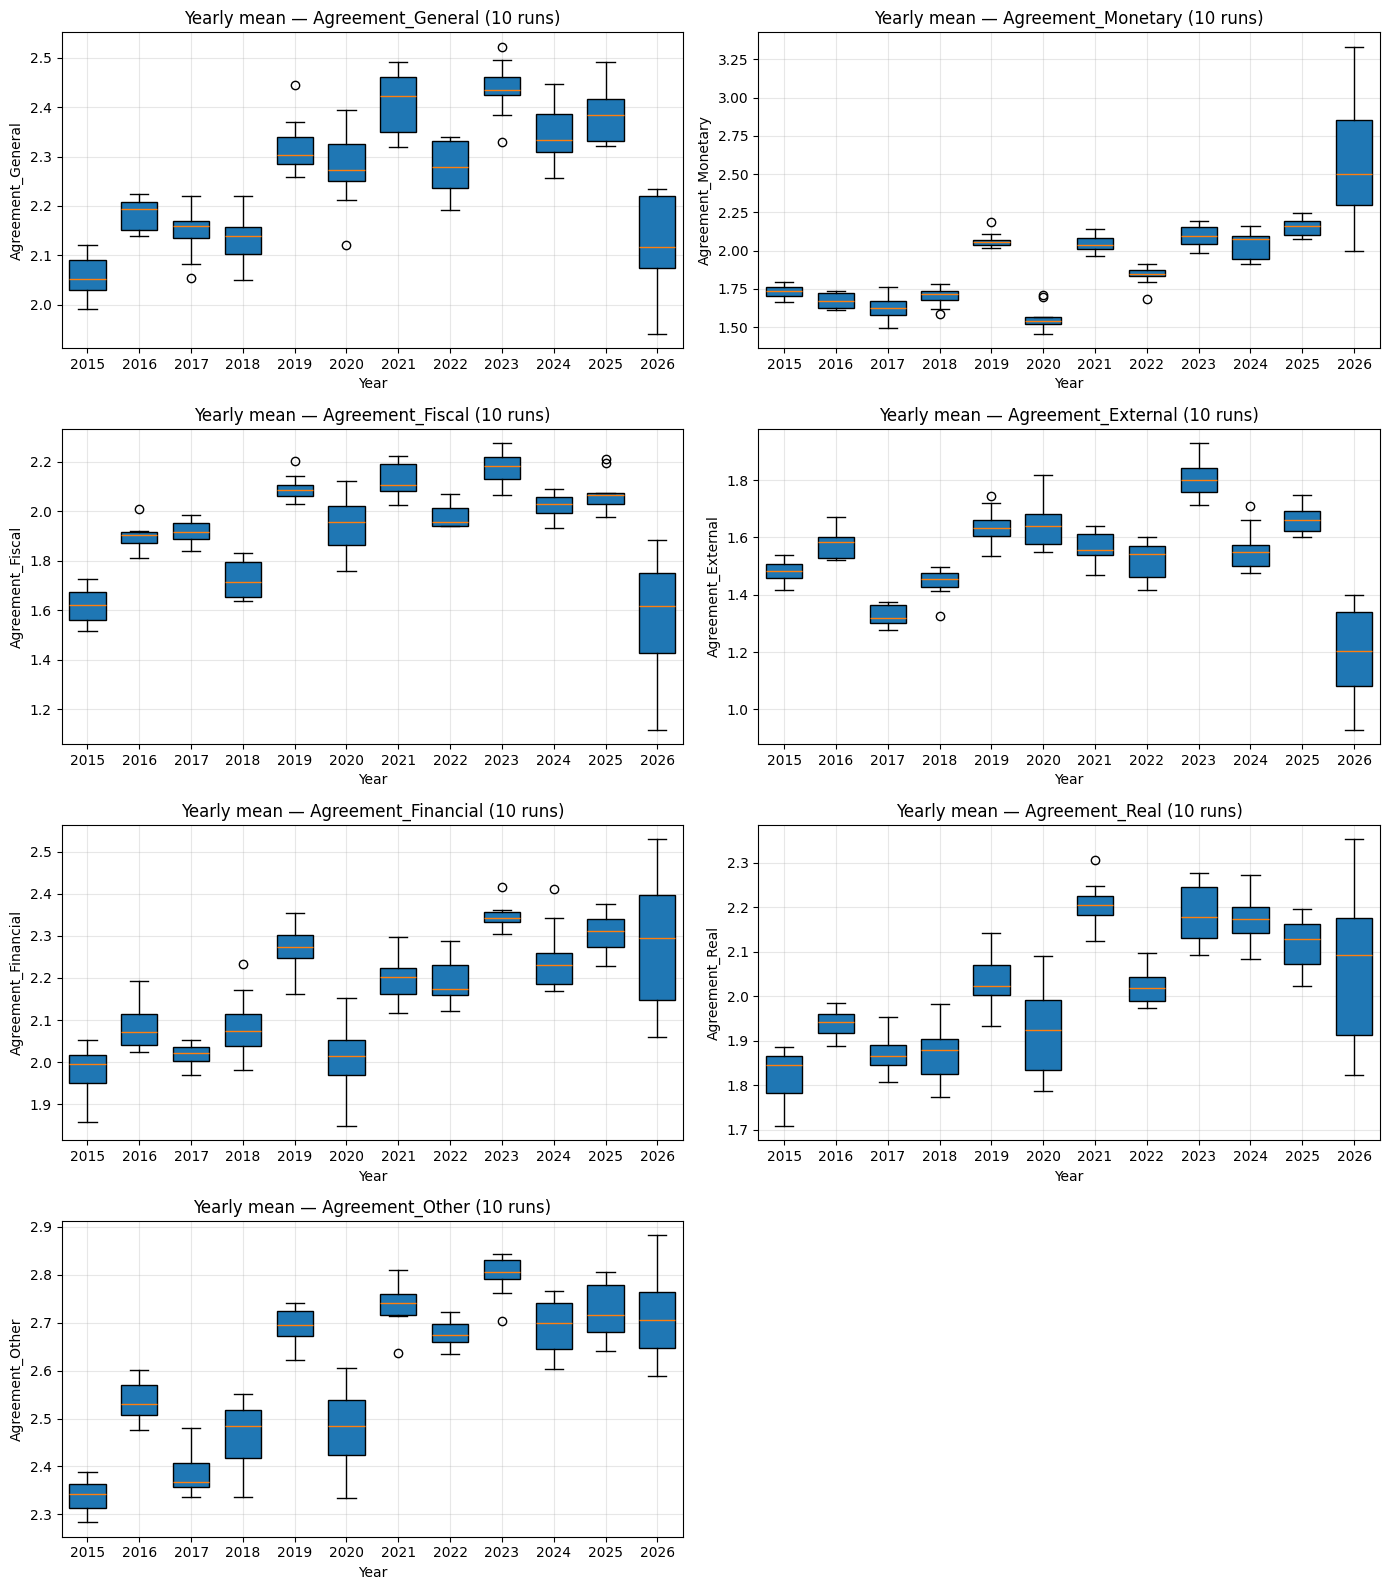

In [15]:
# Box-whisker (boxplot) charts of yearly means across runs for each category (SCORE_COLS)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flat

for idx, c in enumerate(SCORE_COLS):
    ym = yearly_means_by_run(long, c)
    # Each box is a year; the y-values are the means across runs
    years = sorted(ym["year"].unique())
    data = [ym[ym["year"] == y][c].values for y in years]
    axes[idx].boxplot(data, positions=years, widths=0.7, patch_artist=True)
    axes[idx].set_title(f"Yearly mean — {c} (10 runs)")
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(c)
    axes[idx].set_xticks(years)
    axes[idx].grid(alpha=0.3)
axes[-1].axis("off")  # Hide the empty subplot if SCORE_COLS < 8
plt.tight_layout()
plt.show()

## 3 · Fixed-effects trends across runs

Two-way FE regression `Agreement_<sector> ~ C(year) + C(country)` with
country-clustered SEs, Stata-style margins (year effects holding country
composition fixed). Reused verbatim from `notebook_check_new_prompt_v2.ipynb`.

Here we fit it **separately for each of the 10 runs** and overlay the
FE-adjusted year trends, so you can see whether the composition-adjusted signal
is stable under model randomness — the FE analogue of Section 2.

In [16]:
def compute_fe_margins(df, sector_col, year_min=YEAR_MIN, year_max=YEAR_MAX):
    """Two-way FE regression + Stata-style margins for one Agreement_* column.

    Returns a per-year DataFrame with the FE-adjusted mean (+ 95% CI from
    country-clustered variation) and the naive yearly mean. None if too thin."""
    data = df.dropna(subset=[sector_col, "year", "country"]).copy()
    data["year"] = data["year"].astype(int)
    data = data[(data["year"] >= year_min) & (data["year"] <= year_max)]
    if data["year"].nunique() < 2 or data["country"].nunique() < 2:
        return None

    model = smf.ols(f"Q('{sector_col}') ~ C(year) + C(country)", data=data
                    ).fit(cov_type="cluster", cov_kwds={"groups": data["country"]})

    margins = []
    for y in sorted(data["year"].unique()):
        temp = data.copy(); temp["year"] = y
        margins.append({"year": y, "mean": model.predict(temp).mean()})
    df_margins = pd.DataFrame(margins)

    data["yhat"] = model.fittedvalues
    df_ci = (data.groupby(["year", "country"])["yhat"].mean().reset_index()
             .groupby("year").agg(std=("yhat", "std"), n=("yhat", "count")).reset_index())
    df_margins = df_margins.merge(df_ci, on="year")
    df_margins["se"] = df_margins["std"] / np.sqrt(df_margins["n"])
    df_margins["lower"] = df_margins["mean"] - 1.96 * df_margins["se"]
    df_margins["upper"] = df_margins["mean"] + 1.96 * df_margins["se"]

    df_naive = data.groupby("year")[sector_col].mean().reset_index(name="mean_naive")
    return df_margins.merge(df_naive, on="year")

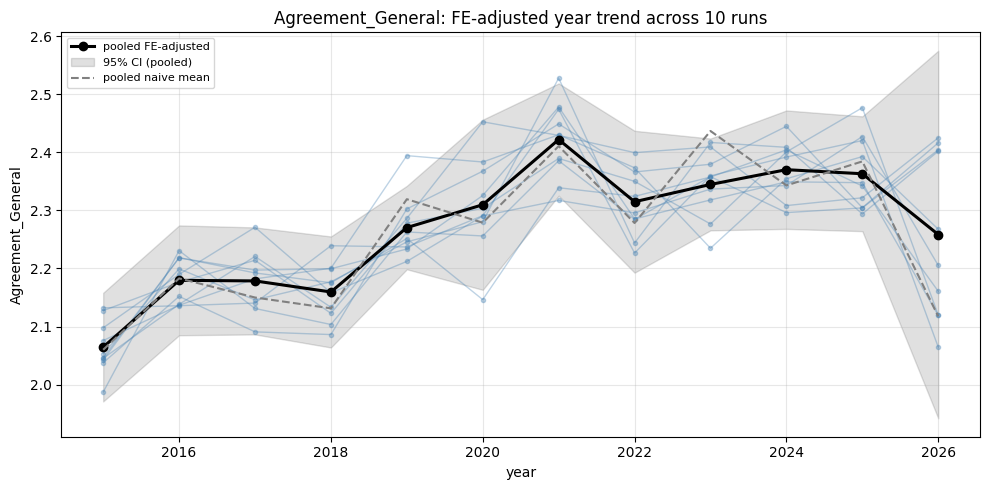

Agreement_General: across-run spread of FE-adjusted mean (avg over years) = 0.193, max = 0.360


In [ ]:
def plot_fe_across_runs(sector_col):
    """Overlay the FE-adjusted year trend from each of the 10 runs, plus the
    pooled fit (all runs stacked) with its 95% CI."""
    fig, ax = plt.subplots(figsize=(10, 5))

    per_run = []
    for r in sorted(long["run"].unique()):
        dp = compute_fe_margins(long[long["run"] == r], sector_col)
        if dp is None:
            continue
        dp["run"] = r
        per_run.append(dp)
        ax.plot(dp["year"], dp["mean"], color="steelblue", alpha=0.35, lw=1, marker="o", ms=3)

    # Pooled fit across all 10 runs (each doc appears 10x) -> tighter CI.
    pooled = compute_fe_margins(long, sector_col)
    if pooled is not None:
        ax.plot(pooled["year"], pooled["mean"], color="black", lw=2.2, marker="o",
                label="pooled FE-adjusted")
        ax.fill_between(pooled["year"], pooled["lower"], pooled["upper"],
                        color="black", alpha=0.12, label="95% CI (pooled)")
        ax.plot(pooled["year"], pooled["mean_naive"], color="grey", ls="--",
                label="pooled naive mean")

    ax.set_title(f"{sector_col}: FE-adjusted year trend across 10 runs")
    ax.set_xlabel("year"); ax.set_ylabel(sector_col); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    if per_run:
        allr = pd.concat(per_run)
        spread = allr.groupby("year")["mean"].agg(lambda x: x.max() - x.min())
        print(f"{sector_col}: across-run spread of FE-adjusted mean "
              f"(avg over years) = {spread.mean():.3f}, max = {spread.max():.3f}")
    return per_run

plot_fe_across_runs("Agreement_General");

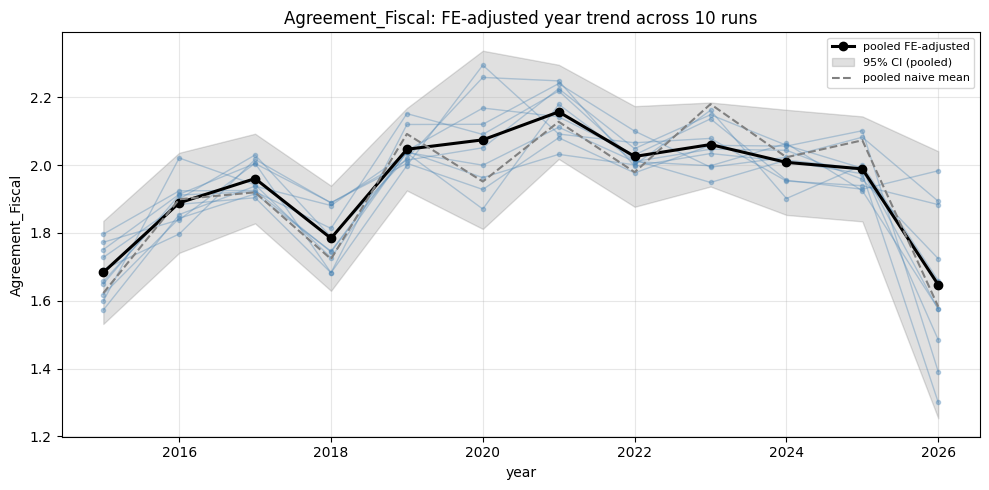

Agreement_Fiscal: across-run spread of FE-adjusted mean (avg over years) = 0.245, max = 0.683


In [18]:
plot_fe_across_runs("Agreement_Fiscal");

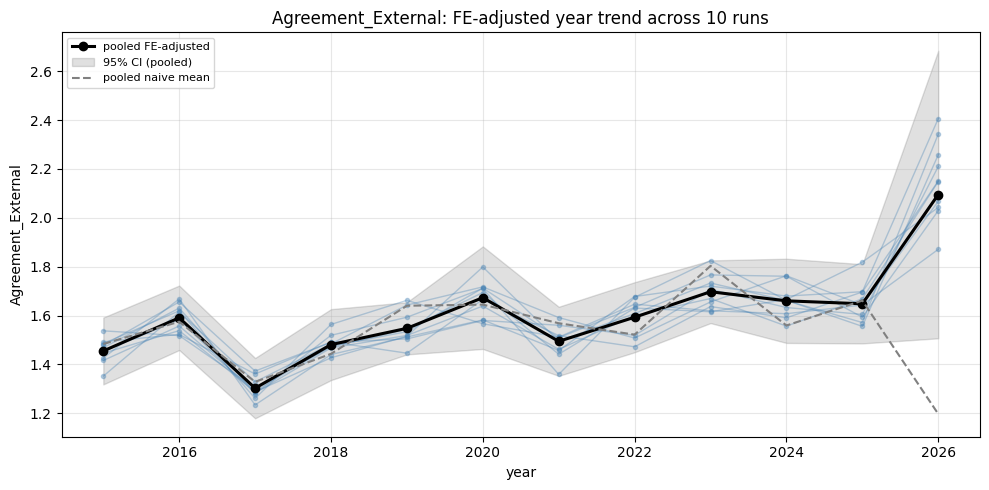

Agreement_External: across-run spread of FE-adjusted mean (avg over years) = 0.226, max = 0.535


In [19]:
plot_fe_across_runs("Agreement_External");

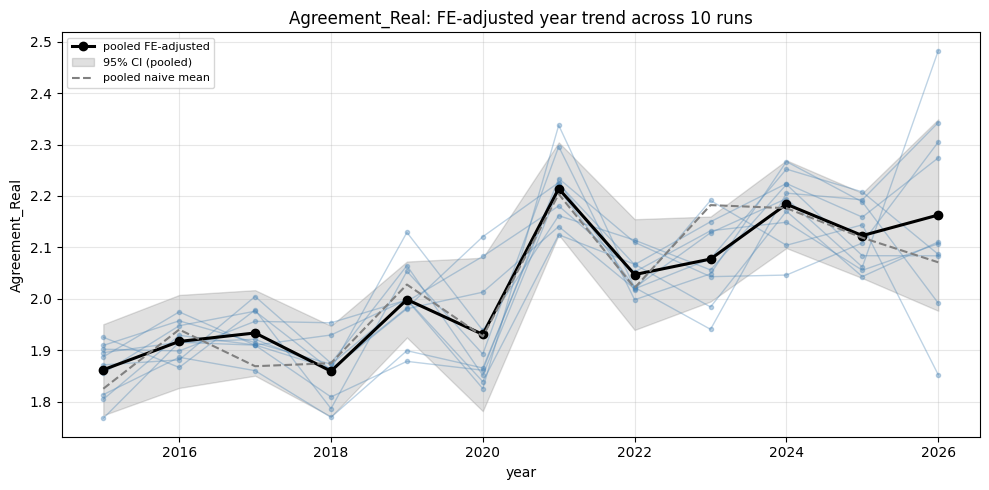

Agreement_Real: across-run spread of FE-adjusted mean (avg over years) = 0.228, max = 0.630


In [20]:
plot_fe_across_runs("Agreement_Real");

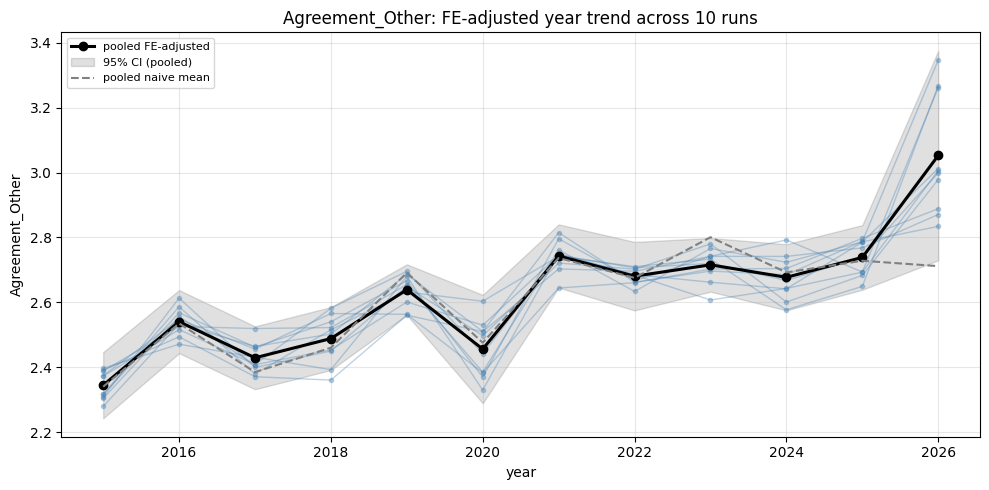

Agreement_Other: across-run spread of FE-adjusted mean (avg over years) = 0.195, max = 0.513


In [21]:
plot_fe_across_runs("Agreement_Other");